# Lab 6: Fuzzy Control Applications

**Module:** Artificial Intelligence  
**Topic:** Fuzzy Logic

---

## Learning Objectives

By the end of this lab, you will be able to:

1. Build a **closed-loop fuzzy controller** that operates on a simulated physical system
2. Understand how a fuzzy inference system **replaces equations** in a control loop
3. Analyse controller behaviour through **time-domain response plots**
4. Tune membership functions and rules to **improve control performance**
5. Compare **Mamdani vs Sugeno** controllers on the same plant
6. Visualise the **control surface** (3D input-output mapping) of a fuzzy controller

---

## Background

Fuzzy logic was first applied to **control systems** by Mamdani in 1974, who used it to regulate a steam engine. Since then, fuzzy controllers have been deployed in industrial applications worldwide — most famously, the **Sendai subway** (1987) in Japan, which used fuzzy logic to achieve smoother acceleration and braking than conventional controllers.

The key insight is that fuzzy rules **replace differential equations**. Instead of deriving a mathematical model of a system, a fuzzy controller captures expert knowledge in linguistic rules like:

> "If the speed error is large and positive, then accelerate hard."

In a **closed-loop control system**, the controller continuously reads sensor values (inputs), computes a control action (output) using fuzzy inference, applies it to the plant (physical system), and then reads the sensors again. This cycle repeats at every time step.

In this lab, we will build a **fuzzy cruise control** system for a simulated car — a system that automatically maintains a target speed by adjusting the throttle.

## Setup

We use **pyfuzzylite** for the fuzzy inference engine, along with NumPy and Matplotlib. We also register custom hedge functions to match the definitions from the lecture slides.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fuzzylite as fl
from fuzzylite import settings

# Register custom hedges to match lecture slide definitions
settings.factory_manager.hedge.constructors["slightly"] = lambda: fl.HedgeLambda("slightly", lambda x: x ** 1.7)
settings.factory_manager.hedge.constructors["more_or_less"] = lambda: fl.HedgeLambda("more_or_less", lambda x: x ** 0.5)
settings.factory_manager.hedge.constructors["a_little"] = lambda: fl.HedgeLambda("a_little", lambda x: x ** 1.3)
settings.factory_manager.hedge.constructors["extremely"] = lambda: fl.HedgeLambda("extremely", lambda x: x ** 3)
settings.factory_manager.hedge.constructors["very_very"] = lambda: fl.HedgeLambda("very_very", lambda x: x ** 4)

print(f"fuzzylite version: {fl.__version__}")
print(f"Available hedges: {list(settings.factory_manager.hedge.constructors.keys())}")

fuzzylite version: 8.0.6
Available hedges: ['any', 'extremely', 'not', 'seldom', 'somewhat', 'very', 'slightly', 'more_or_less', 'a_little', 'very_very']


## Plotting Helpers & Utility Functions

The following functions are provided to produce consistent plots throughout the lab and to handle pyfuzzylite output values safely. **You do not need to modify them** — just call them as instructed in the exercises.

In [2]:
def get_output(engine, name):
    """Extract a scalar float from a fuzzy engine output variable.
    
    pyfuzzylite may return a numpy array instead of a plain float.
    This helper handles both cases safely.
    """
    val = engine.output_variable(name).value
    return float(val.item()) if hasattr(val, 'item') else float(val)

def plot_membership_functions(variable, title=None, ax=None):
    """Plot all membership functions for a pyfuzzylite variable."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3.5))
    x = np.linspace(variable.minimum, variable.maximum, 500)
    for term in variable.terms:
        y = np.array([float(term.membership(xi)) for xi in x])
        ax.plot(x, y, linewidth=2, label=term.name)
    ax.set_xlabel(variable.name)
    ax.set_ylabel('Membership Degree')
    ax.set_title(title or f'Membership Functions: {variable.name}')
    ax.legend(loc='best', fontsize=9)
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.3)
    return ax

def plot_simulation(times, speeds, throttles, errors, target, title="Cruise Control Response"):
    """Plot a 3-panel time-domain response for a control simulation. """
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(times, speeds, 'b-', linewidth=1.5, label='Actual Speed')
    axes[0].axhline(y=target, color='r', linestyle='--', linewidth=1, label=f'Target ({target} km/h)')
    axes[0].set_ylabel('Speed (km/h)')
    axes[0].legend(loc='best')
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(times, throttles, 'g-', linewidth=1.5)
    axes[1].axhline(y=0, color='gray', linestyle=':', linewidth=0.5)
    axes[1].set_ylabel('Throttle')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(times, errors, 'r-', linewidth=1.5)
    axes[2].axhline(y=0, color='gray', linestyle=':', linewidth=0.5)
    axes[2].set_ylabel('Speed Error (km/h)')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_comparison(times, speed_dict, target, title="Controller Comparison"):
    """Overlay multiple speed traces for comparison."""
    plt.figure(figsize=(10, 5))
    for label, speeds in speed_dict.items():
        plt.plot(times, speeds, linewidth=1.5, label=label)
    plt.axhline(y=target, color='r', linestyle='--', linewidth=1, label=f'Target ({target} km/h)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Speed (km/h)')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_control_surface(engine, input1_name, input2_name, output_name, resolution=50):
    """Generate and plot the 3D control surface for a 2-input, 1-output fuzzy system. """
    iv1 = engine.input_variable(input1_name)
    iv2 = engine.input_variable(input2_name)

    x1 = np.linspace(iv1.minimum, iv1.maximum, resolution)
    x2 = np.linspace(iv2.minimum, iv2.maximum, resolution)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros_like(X1)

    for i in range(len(x2)):
        for j in range(len(x1)):
            iv1.value = float(x1[j])
            iv2.value = float(x2[i])
            engine.process()
            Z[i, j] = get_output(engine, output_name)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X1, X2, Z, cmap='RdYlGn', edgecolor='none', alpha=0.85)
    ax.set_xlabel(input1_name)
    ax.set_ylabel(input2_name)
    ax.set_zlabel(output_name)
    ax.set_title(f'Control Surface: {engine.name}')
    fig.colorbar(surf, shrink=0.5, aspect=10, label=output_name)
    plt.tight_layout()
    plt.show()

    return X1, X2, Z

print("Plotting helpers loaded.")

Plotting helpers loaded.


## Exercise 1: The Car Plant Model

Before building a controller, we need a **plant** — the system being controlled. Our plant is a simplified car with these physics:

*   **Mass:** 1,200 kg
*   **Drag force:** proportional to speed² (aerodynamic resistance)
*   **Throttle force:** proportional to the controller's output
*   **External disturbances:** hills (gravity component), headwinds

At each time step, Newton's second law gives us:

$$a = \frac{F_{throttle} - F_{drag} - F_{disturbance}}{m}$$

### 1.1 — Implement the Plant

Complete the `CarPlant` class below. The `step()` method should:

1. Compute the drag force from the current speed
2. Compute the net force (throttle – drag – disturbance)
3. Update the speed using $v_{new} = v + a \cdot \Delta t$
4. Return the new speed

In [3]:
class CarPlant:
    """Simple car dynamics for cruise control simulation."""

    def __init__(self, mass=1200, drag_coeff=0.3, force_gain=30, dt=0.1):
        self.mass = mass                # kg
        self.drag_coeff = drag_coeff    # aerodynamic drag coefficient
        self.force_gain = force_gain    # Newtons per unit of throttle output
        self.dt = dt                    # simulation time step (seconds)
        self.speed = 0.0                # current speed in km/h
        self.prev_speed = 0.0            # previous speed (for acceleration calc)

    def reset(self, initial_speed):
        """Reset the plant to a given initial speed."""
        self.speed = initial_speed
        self.prev_speed = initial_speed

    def step(self, throttle, disturbance=0.0):
        """
        Advance one time step.
        
        Parameters
        ----------
        throttle : float
            Controller output (can be negative for braking).
        disturbance : float
            External force in Newtons (e.g. hill gravity, headwind).
            
        Returns
        -------
        speed : float
            Updated speed in km/h.
        """
        self.prev_speed = self.speed

        # Compute throttle force
        throttle_force = throttle * self.force_gain

        # TODO: Compute speed in m/s (divide km/h by 3.6)
        speed_ms = self.speed / 3.6

        # Compute drag force
        drag_force = self.drag_coeff * speed_ms ** 2
        
        # TODO: Compute net force and acceleration
        net_force = throttle_force - drag_force - disturbance

        # TODO: Compute acceleration
        acceleration_ms2 = net_force / self.mass

        speed_change_kmh = acceleration_ms2 * self.dt * 3.6  # convert m/s² back to km/h change

        self.speed = max(0.0, self.speed + speed_change_kmh)
        return self.speed

    def get_acceleration(self):
        """Return acceleration in km/h per second."""
        return (self.speed - self.prev_speed) / self.dt

### 1.2 — Test Without a Controller

Set the car to an initial speed of **100 km/h** and simulate 200 steps with **zero throttle** (i.e. coasting). The car should gradually slow down due to drag.

Plot the speed over time.

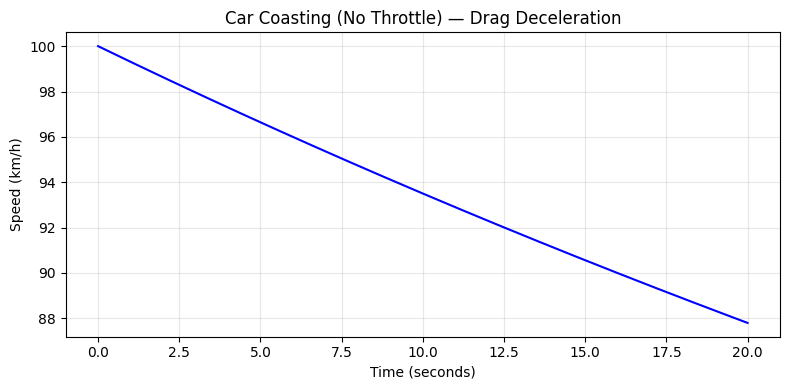

Speed after 20s: 87.80 km/h


In [5]:
# TODO: Create a CarPlant object called "plant"
plant = CarPlant()
# TODO: reset the plant to 100 km/h
plant.reset(initial_speed=100.0)

times_coast = [0.0]
speeds_coast = [100.0]

for step in range(1, 201):
    t = step * plant.dt
    speed = plant.step(throttle=0.0)
    # Recording time and speed over simulation
    times_coast.append(t)
    speeds_coast.append(speed)

plt.figure(figsize=(8, 4))
plt.plot(times_coast, speeds_coast, 'b-', linewidth=1.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (km/h)')
plt.title('Car Coasting (No Throttle) — Drag Deceleration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Speed after 20s: {speeds_coast[-1]:.2f} km/h")

## Exercise 2: Build the Mamdani Cruise Controller

### 2.1 — Define the Fuzzy Inference System

The controller has:

*   **Input 1: speed_error** = target_speed – actual_speed (range: –30 to +30 km/h)
    Terms: `large_negative`, `small_negative`, `zero`, `small_positive`, `large_positive` 
*   **Input 2: acceleration** = rate of change of speed (range: –5 to +5 km/h/s)
    Terms: `braking`, `steady`, `accelerating` 
*   **Output: throttle** (range: –50 to +50)
    Terms: `brake_hard`, `brake_light`, `maintain`, `accelerate_light`, `accelerate_hard` 

The rules encode common-sense driving knowledge:

| Rule | speed_error | acceleration | → throttle |
|------|-------------|--------------|------------|
| 1 | large_negative | any | brake_hard |
| 2 | small_negative | accelerating | brake_light |
| 3 | small_negative | steady | brake_light |
| 4 | small_negative | braking | maintain |
| 5 | zero | any | maintain |
| 6 | small_positive | braking | accelerate_light |
| 7 | small_positive | steady | accelerate_light |
| 8 | small_positive | accelerating | maintain |
| 9 | large_positive | any | accelerate_hard |

In [ ]:
def create_mamdani_cruise_controller():
    """Create a Mamdani fuzzy cruise controller."""
    engine = fl.Engine(
        name="CruiseControl_Mamdani",
        input_variables=[
            fl.InputVariable(
                name="speed_error", minimum=-30, maximum=30,
                terms=[
                    fl.Trapezoid("large_negative", -30, -30, -15, -5),
                    fl.Triangle("small_negative", -10, -5, 0),
                    # TODO: Create the other 3 fuzzy sets
                    fl.Triangle("zero", -5, 0, 5),
                    fl.Triangle("small_positive", 0, 5, 10),
                    fl.Trapezoid("large_positive", 5, 15, 30, 30),
                ]
            ),
            fl.InputVariable(
                # TODO: Define "acceleration", including its
                # universe of discourse and fuzzy sets
                name="acceleration", minimum=-5, maximum=5,
                terms=[
                    fl.Trapezoid("braking", -5, -5, -2, 0),
                    fl.Triangle("steady", -1, 0, 1),
                    fl.Trapezoid("accelerating", 0, 2, 5, 5),
                ]
            ),
        ],
        output_variables=[
            fl.OutputVariable(
                name="throttle", minimum=-50, maximum=50,
                aggregation=fl.Maximum(),
                defuzzifier=fl.Centroid(200),
                # Create the output fuzzy sets
                terms=[
                    fl.Trapezoid("brake_hard", -50, -50, -30, -10),
                    fl.Triangle("brake_light", -20, -10, 0),
                    fl.Triangle("maintain", -5, 0, 5),
                    fl.Triangle("accelerate_light", 0, 10, 20),
                    fl.Trapezoid("accelerate_hard", 10, 30, 50, 50),
                ]
            ),
        ],
        rule_blocks=[
            fl.RuleBlock(
                name="rules",
                conjunction=fl.Minimum(),
                disjunction=fl.Maximum(),
                implication=fl.Minimum(),
                activation=fl.General(),
                rules=[
                    fl.Rule.create("if speed_error is large_negative then throttle is brake_hard"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is accelerating then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is steady then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is braking then throttle is maintain"),
                    fl.Rule.create("if speed_error is zero then throttle is maintain"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is braking then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is steady then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is accelerating then throttle is maintain"),
                    # TODO: Create rules 8 and 9
                    fl.Rule.create("if speed_error is large_positive then throttle is accelerate_hard"),
                ]
            ),
        ]
    )
    return engine

mamdani = create_mamdani_cruise_controller()
print(f"Engine: {mamdani.name}, Rules: {len(mamdani.rule_blocks[0].rules)}")

### 2.2 — Visualise the Membership Functions

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_membership_functions(mamdani.input_variable("speed_error"), ax=axes[0])
plot_membership_functions(mamdani.input_variable("acceleration"), ax=axes[1])
plot_membership_functions(mamdani.output_variable("throttle"), ax=axes[2])

plt.tight_layout()
plt.show()

### 2.3 — Quick Sanity Check

Before running a full simulation, verify the controller responds sensibly to a few test inputs:

| speed_error | acceleration | Expected throttle direction |
|-------------|--------------|----------------------------|
| +20 (too slow) | 0 (steady) | Strong positive (accelerate) |
| –15 (too fast) | +2 (still speeding up) | Strong negative (brake) |
| +3 (slightly slow) | –1 (slowing down) | Mild positive |

In [ ]:
test_cases = [
    (20.0, 0.0, "Too slow, steady"),
    (-15.0, 2.0, "Too fast, still accelerating"),
    (3.0, -1.0, "Slightly slow, decelerating"),
    (0.0, 0.0, "On target, steady"),
]

print(f"{'Description':<35} {'Error':>6} {'Accel':>6} {'Throttle':>10}")
print("-" * 62)

for err, acc, desc in test_cases:
    mamdani.input_variable("speed_error").value = err
    mamdani.input_variable("acceleration").value = acc
    mamdani.process()
    throttle = get_output(mamdani, "throttle")
    print(f"{desc:<35} {err:>6.1f} {acc:>6.1f} {throttle:>10.2f}")

## Exercise 3: Closed-Loop Simulation

Now we close the loop: at each time step, the controller reads the plant's state, computes a throttle value, and feeds it back into the plant.

### 3.1 — Run the Control Loop

Complete the simulation function below. The function should:

1. At each time step, compute `speed_error = target - current_speed` 
2. Get the acceleration from the plant
3. Clamp both values to the controller's input ranges
4. Run the fuzzy inference engine
5. Feed the throttle output into the plant's `step()` method

In [ ]:
def run_simulation(engine, plant, target_speed, initial_speed, n_steps=500, disturbance_fn=None):
    """
    Run a closed-loop fuzzy control simulation.
    
    Parameters
    ----------
    engine : fl.Engine
        The fuzzy inference engine (controller).
    plant : CarPlant
        The plant model.
    target_speed : float
        Desired speed in km/h.
    initial_speed : float
        Starting speed in km/h.
    n_steps : int
        Number of simulation steps.
    disturbance_fn : callable or None
        A function f(t) -> force (Newtons) for external disturbances.
        
    Returns
    -------
    dict with keys: 'times', 'speeds', 'throttles', 'errors'
    """
    plant.reset(initial_speed)

    times = [0.0]
    speeds = [initial_speed]
    throttles = [0.0]
    errors = [target_speed - initial_speed]

    for step in range(1, n_steps + 1):
        t = step * plant.dt

        speed_error = target_speed - plant.speed
        acceleration = plant.get_acceleration()

        se_clamped = np.clip(speed_error, -30, 30)
        ac_clamped = np.clip(acceleration, -5, 5)

        engine.input_variable("speed_error").value = float(se_clamped)
        engine.input_variable("acceleration").value = float(ac_clamped)
        engine.process()
        throttle = get_output(engine, "throttle")

        dist = disturbance_fn(t) if disturbance_fn else 0.0
        new_speed = plant.step(throttle, disturbance=dist)

        times.append(t)
        speeds.append(new_speed)
        throttles.append(throttle)
        errors.append(target_speed - new_speed)

    return {'times': times, 'speeds': speeds, 'throttles': throttles, 'errors': errors}

### 3.2 — Acceleration from 60 to 100 km/h

Run the simulation starting from **60 km/h** with a target of **100 km/h**. Use the 3-panel plot to visualise the response.

In [ ]:
plant = CarPlant()
result = run_simulation(mamdani, plant, target_speed=100, initial_speed=60, n_steps=500)

plot_simulation(result['times'], result['speeds'], result['throttles'], result['errors'], 
                target=100, title="Mamdani Cruise Control: 60 -> 100 km/h")

# Performance metrics
final_speed = result['speeds'][-1]
steady_state_error = 100 - final_speed
max_speed = max(result['speeds'])
overshoot = max_speed - 100

print(f"Final speed: {final_speed:.2f} km/h")
print(f"Steady-state error: {steady_state_error:.2f} km/h")
print(f"Max overshoot: {overshoot:.2f} km/h")

### 3.3 — Observe the Steady-State Error

You should notice that the car **never quite reaches** 100 km/h. It settles a few km/h below the target. This happens because:

*   When the speed error enters the "**zero**" region (within ±5 km/h), the controller outputs "**maintain**" — which centres around zero throttle.
*   But the car always experiences **aerodynamic drag**, which requires a non-zero throttle just to hold speed.
*   The controller has no **integral action** (it doesn't accumulate error), so it cannot eliminate this offset.

This is a **fundamental limitation of proportional-only fuzzy controllers** — and a key difference from a PID controller.

**Question:** How might you fix the steady-state error? Think of at least two different approaches before moving to Exercise 5.

## Exercise 4: Disturbance Rejection

A good controller should recover when external disturbances affect the plant. We will simulate the car encountering a **hill** (opposing force from gravity) and a **headwind gust**.

### 4.1 — Hill Disturbance

Start the car at **100 km/h** (already at target). Between t=5s and t=15s, apply a hill disturbance of **600 N** (simulating a steep uphill gradient).

Observe how the controller responds: does the speed drop? How quickly does it recover?

In [ ]:
def hill_disturbance(t):
    """600 N opposing force between t=5 and t=15 seconds."""
    return 600.0 if 5 <= t <= 15 else 0.0

# TODO: Create and run the simulation according to the description in the markdown cell above
# passing "hill_disturbance" as the disturbance function
# Tip: See the "run_simulation" definition in Exercise 3.1 and an example of its use with 
# only 5 arguments (note: here you will need 6 arguments)


plot_simulation(result_hill['times'], result_hill['speeds'], result_hill['throttles'], 
                result_hill['errors'], target=100, title='Disturbance Rejection: Hill (600 N, t=5-15s)')

min_speed = min(result_hill['speeds'])
print(f"Minimum speed during hill: {min_speed:.2f} km/h")
print(f"Speed drop: {100 - min_speed:.2f} km/h")
print(f"Final speed (after hill): {result_hill['speeds'][-1]:.2f} km/h")

### 4.2 — Wind Gust Disturbance

Now simulate a sudden **headwind gust** at t=10s: a sharp 1000 N force lasting only 2 seconds.

In [ ]:
# Tip: See Exercise 4.1

# TODO: Define a wind gust disturbance function "wind_gust"
# applying 1000 N between t=10 and t=12

# TODO: Run the simulation from 100 km/h

# TODO: Plot the results


min_speed_wind = min(result_wind['speeds'])
print(f"Minimum speed during gust: {min_speed_wind:.2f} km/h")
print(f"Speed drop: {100 - min_speed_wind:.2f} km/h")

## Exercise 5: Controller Tuning

The steady-state error from Exercise 3 is a real problem. In this exercise, you will **modify** the controller to improve its performance.

### 5.1 — Strategy A: Shift the "maintain" Output

The simplest fix is to shift the "**maintain**" output MF so that its centre is slightly positive, compensating for drag. Instead of `Triangle("maintain", -5, 0, 5)`, try `Triangle("maintain", -2, 3, 8)`.

Create a new engine with this change, run the simulation, and compare with the original.

In [ ]:
# TODO: Code here a modified controller with shifted "maintain" MF
# Tip: Copy the code from Exercise 2.1, changing only the "maintain" MF
# according to the instruction in the markdown cell just above


# Run the 60->100 simulation
tuned_a = create_tuned_controller_A()
result_a = run_simulation(tuned_a, plant, target_speed=100, initial_speed=60, n_steps=500)
print(f"Tuned A - Final speed: {result_a['speeds'][-1]:.2f}, SSE: {100 - result_a['speeds'][-1]:.2f}")

### 5.2 — Strategy B: Expand the "zero" Rules

Another approach: replace the single "zero error → maintain" rule with three rules that account for acceleration. The key addition is a rule that provides gentle acceleration when the error is near zero but the car is decelerating (fighting drag):

> *"If speed_error is zero and acceleration is braking then throttle is accelerate_light"

This targets the specific condition that causes steady-state error. The other two rules preserve the original "maintain" behaviour when the car is steady or accelerating:

> *"If speed_error is zero and acceleration is steady then throttle is maintain"

> *"If speed_error is zero and acceleration is accelerating then throttle is maintain"

This expands the rule base from 9 to 11 rules.

In [ ]:
# TODO: Code here a modified controller with the extra rules and compare
# Tip: Copy the code from Exercise 2.1, adding the extra rules
# according to the instruction in the markdown cell just above


# Run the 60->100 simulation
tuned_b = create_tuned_controller_B()
result_b = run_simulation(tuned_b, plant, target_speed=100, initial_speed=60, n_steps=500)
print(f"Tuned B - Final speed: {result_b['speeds'][-1]:.2f}, SSE: {100 - result_b['speeds'][-1]:.2f}")

### 5.3 — Compare All Three

Use `plot_comparison()` to overlay the original, tuned-A, and tuned-B speed traces on a single plot.

In [ ]:
# Overlay comparison using plot_comparison()
plot_comparison(
    result['times'],
    {
        'Original': result['speeds'],
        'Tuned A (shifted maintain)': result_a['speeds'],
        'Tuned B (extra rule)': result_b['speeds'],
    },
    target=100,
    title='Controller Tuning Comparison: 60 -> 100 km/h'
)

### 5.4 — Challenge: Beat Tuned A

Strategy A reduced the steady-state error from 2.80 to 1.73 km/h. Strategy B had almost no effect — can you explain why? (*Hint: at the target speed, drag causes only a very gentle deceleration. Check what membership degrees the "braking" and "steady" terms give for such small values. Does the new rule ever fire strongly enough to matter?*)

**Your challenge:** Design a tuning strategy that achieves a steady-state error **below 1.0 km/h** on the 60 → 100 km/h scenario without introducing overshoot greater than 2 km/h.

Some ideas to explore (or invent your own):

*   Narrow the "zero" error term (i.e. fuzzy set) so the controller stays in "small_positive" longer
*   Shift the "maintain" output further than Strategy A did
*   Add a new output term (e.g. a gentle "cruise" triangle centred around +5)
*   Change the consequent of an existing rule rather than adding new rules

Report your best SSE and maximum overshoot.

In [ ]:
# Code your own fuzzy controller here and try to beat Tuned A one.

# Run the 60->100 simulation for your controller here and compare to Tuned A.

# Then code and run an overlay comparison using plot_comparison()

## Exercise 6: Sugeno Controller

The Sugeno model replaces the output membership functions with **constants** (zero-order Sugeno) and uses a **weighted average** instead of defuzzification.

### 6.1 — Build the Sugeno Controller

Create a Sugeno version of the cruise controller. The input variables and rules remain the same — only the output variable changes:

| Output Term | Constant Value |
|-------------|----------------|
| brake_hard | –40 |
| brake_light | –10 |
| maintain | 0 |
| accelerate_light | 10 |
| accelerate_hard | 40 |

Use `fl.Constant` for the output terms and `fl.WeightedAverage("TakagiSugeno")` as the defuzzifier.

In [ ]:
def create_sugeno_cruise_controller():
    """Create a Sugeno (zero-order) fuzzy cruise controller."""
    engine = fl.Engine(
        name="CruiseControl_Sugeno",
        input_variables=[
            # TODO: Define the input variables here
            # Tip: The same as Exercise 2.1
            # Remember: Mamdani & Sugeno fuzzify inputs the same way
            fl.InputVariable(
                name="speed_error", minimum=-30, maximum=30,
                terms=[
                    fl.Trapezoid("large_negative", -30, -30, -15, -5),
                    fl.Triangle("small_negative", -10, -5, 0),
                    fl.Triangle("zero", -5, 0, 5),
                    fl.Triangle("small_positive", 0, 5, 10),
                    fl.Trapezoid("large_positive", 5, 15, 30, 30),
                ]
            ),
            fl.InputVariable(
                name="acceleration", minimum=-5, maximum=5,
                terms=[
                    fl.Trapezoid("braking", -5, -5, -2, 0),
                    fl.Triangle("steady", -1, 0, 1),
                    fl.Trapezoid("accelerating", 0, 2, 5, 5),
                ]
            ),
        ],
        output_variables=[
            fl.OutputVariable(
                name="throttle", minimum=-50, maximum=50,
                aggregation=fl.Maximum(),
                defuzzifier=fl.WeightedAverage("TakagiSugeno"),
                terms=[
                    fl.Constant("brake_hard", -40),
                    fl.Constant("brake_light", -10),
                    fl.Constant("maintain", 0),
                    fl.Constant("accelerate_light", 10),
                    fl.Constant("accelerate_hard", 40),
                ]
            ),
        ],
        rule_blocks=[
            fl.RuleBlock(
                name="rules",
                conjunction=fl.Minimum(),
                disjunction=fl.Maximum(),
                implication=fl.AlgebraicProduct(),
                activation=fl.General(),
                rules=[
                    # TODO: Define the rules here
                    # Tip: The same as Exercise 2.1
                    fl.Rule.create("if speed_error is large_negative then throttle is brake_hard"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is accelerating then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is steady then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is braking then throttle is maintain"),
                    fl.Rule.create("if speed_error is zero then throttle is maintain"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is braking then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is steady then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is accelerating then throttle is maintain"),
                    fl.Rule.create("if speed_error is large_positive then throttle is accelerate_hard"),
                ]
            ),
        ]
    )
    return engine

### 6.2 — Compare Mamdani vs Sugeno

Run both controllers on the same 60→100 km/h scenario and overlay the results.

In [ ]:
# Create the Sugeno engine, run the simulation, and compare
sugeno = create_sugeno_cruise_controller()
result_sugeno = run_simulation(sugeno, plant, target_speed=100, initial_speed=60, n_steps=500)

plot_comparison(
    result['times'],
    {
        'Mamdani (COG)': result['speeds'],
        'Sugeno': result_sugeno['speeds'],
    },
    target=100,
    title='Mamdani vs Sugeno Cruise Control'
)

print(f"Mamdani SSE: {100 - result['speeds'][-1]:.2f} km/h")
print(f"Sugeno SSE: {100 - result_sugeno['speeds'][-1]:.2f} km/h")

**Question:** Which controller reaches the target faster? Which has a smaller steady-state error? Based on the lecture slides, why is Sugeno often preferred for control applications despite Mamdani being "more intuitive"?

## Exercise 7: Control Surface Visualisation

A **control surface** shows the complete input–output mapping of a fuzzy controller as a 3D surface. Each point on the surface represents the controller's output for a given combination of inputs.

### 7.1 — Generate the Mamdani Control Surface

In [ ]:
X1, X2, Z = plot_control_surface(mamdani, "speed_error", "acceleration", "throttle", resolution=50)

### 7.2 — Generate a 3-D Animated Mamdani Control Surface

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='RdYlGn', edgecolor='none', alpha=0.85)
ax.set_xlabel("speed_error")
ax.set_ylabel("acceleration")
ax.set_zlabel("throttle")
ax.set_title(f"Control Surface: {mamdani.name}")
fig.colorbar(ax.collections[0], shrink=0.5, aspect=10, label="throttle")

def rotate(angle):
    ax.view_init(elev=25, azim=angle)

anim = FuncAnimation(fig, rotate, frames=range(0, 360, 2), interval=50)
plt.close()
HTML(anim.to_jshtml())

### 7.3 — Generate the Sugeno Control Surface

If you completed Exercise 6, generate the Sugeno surface and compare. The Sugeno surface could look **smoother** because it interpolates between constants rather than defuzzifying distributed fuzzy sets.

In [ ]:
X1s, X2s, Zs = plot_control_surface(sugeno, "speed_error", "acceleration", "throttle", resolution=50)

## Exercise 8: Water Tank Level Controller

Design your own fuzzy controller for a **water tank level control** system:

*   **Plant:** A tank where water flows in (controlled by a valve) and out (constant drain + variable demand)
*   **Input 1:** `level_error` = target_level – actual_level
*   **Input 2:** `rate_of_change` = how fast the level is changing
*   **Output:** `valve_opening` (0% = closed, 100% = fully open)

Use the simulation pattern from Exercise 3 and adapt it for a water tank.

In [ ]:
# #SOLUTION
class WaterTank:
    """Simple water tank model."""
    def __init__(self, capacity=100, drain_rate=2.0, dt=0.1):
        self.capacity = capacity
        self.drain_rate = drain_rate
        self.dt = dt
        self.level = 0.0
        self.prev_level = 0.0

    def reset(self, initial_level):
        self.level = initial_level
        self.prev_level = initial_level

    def step(self, valve_opening, demand=0.0):
        self.prev_level = self.level
        inflow = valve_opening * 0.1 # scale valve to flow rate
        outflow = self.drain_rate + demand
        self.level = np.clip(self.level + (inflow - outflow) * self.dt, 0, self.capacity)
        return self.level

    def get_rate(self):
        return (self.level - self.prev_level) / self.dt

tank_controller = fl.Engine(
    name="WaterTankController",
    input_variables=[
        fl.InputVariable(name="level_error", minimum=-50, maximum=50,
            terms=[
                fl.Trapezoid("large_negative", -50, -50, -20, -5),
                fl.Triangle("small_negative", -15, -5, 0),
                fl.Triangle("zero", -5, 0, 5),
                fl.Triangle("small_positive", 0, 5, 15),
                fl.Trapezoid("large_positive", 5, 20, 50, 50),
            ]),
        fl.InputVariable(name="rate_of_change", minimum=-10, maximum=10,
            terms=[
                fl.Trapezoid("draining", -10, -10, -3, 0),
                fl.Triangle("stable", -2, 0, 2),
                fl.Trapezoid("filling", 0, 3, 10, 10),
            ]),
    ],
    output_variables=[
        fl.OutputVariable(name="valve", minimum=0, maximum=100,
            aggregation=fl.Maximum(), defuzzifier=fl.Centroid(200),
            terms=[
                fl.Trapezoid("closed", 0, 0, 5, 15),
                fl.Triangle("partial", 10, 30, 50),
                fl.Triangle("half", 30, 50, 70),
                fl.Triangle("mostly_open", 50, 70, 90),
                fl.Trapezoid("fully_open", 85, 95, 100, 100),
            ]),
    ],
    rule_blocks=[
        fl.RuleBlock(name="rules", conjunction=fl.Minimum(), disjunction=fl.Maximum(),
            implication=fl.Minimum(), activation=fl.General(),
            rules=[
                fl.Rule.create("if level_error is large_positive then valve is fully_open"),
                fl.Rule.create("if level_error is small_positive and rate_of_change is draining then valve is mostly_open"),
                fl.Rule.create("if level_error is small_positive and rate_of_change is stable then valve is mostly_open"),
                fl.Rule.create("if level_error is small_positive and rate_of_change is filling then valve is half"),
                fl.Rule.create("if level_error is zero then valve is half"),
                fl.Rule.create("if level_error is small_negative and rate_of_change is draining then valve is half"),
                fl.Rule.create("if level_error is small_negative and rate_of_change is stable then valve is partial"),
                fl.Rule.create("if level_error is small_negative and rate_of_change is filling then valve is closed"),
                fl.Rule.create("if level_error is large_negative then valve is closed"),
            ]),
    ]
)

# Run simulation
tank = WaterTank()
tank.reset(30)
target_level = 60
n_steps = 1000

times_t, levels, valves, errors_t = [0.0], [30.0], [0.0], [30.0]

for s in range(1, n_steps + 1):
    t = s * tank.dt
    err = target_level - tank.level
    rate = tank.get_rate()
    
    err_c = np.clip(err, -50, 50)
    rate_c = np.clip(rate, -10, 10)
    
    tank_controller.input_variable("level_error").value = float(err_c)
    tank_controller.input_variable("rate_of_change").value = float(rate_c)
    tank_controller.process()
    valve = get_output(tank_controller, "valve")
    
    # Add demand surge at t=50s
    demand = 5.0 if 50 <= t <= 70 else 0.0
    tank.step(valve, demand=demand)
    
    times_t.append(t)
    levels.append(tank.level)
    valves.append(valve)
    errors_t.append(target_level - tank.level)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(times_t, levels, 'b-', linewidth=1.5)
axes[0].axhline(y=target_level, color='r', linestyle='--', label=f'Target ({target_level}%)')
axes[0].axvspan(50, 70, alpha=0.15, color='orange', label='Demand surge')
axes[0].set_ylabel('Level (%)')
axes[0].legend()
axes[0].set_title('Water Tank Fuzzy Control')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_t, valves, 'g-', linewidth=1.5)
axes[1].set_ylabel('Valve Opening (%)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(times_t, errors_t, 'r-', linewidth=1.5)
axes[2].axhline(y=0, color="gray", linestyle=':')
axes[2].set_ylabel('Level Error')
axes[2].set_xlabel('Time (seconds)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final level: {levels[-1]:.2f}%")
print(f"SSE: {target_level - levels[-1]:.2f}%")

## Summary

In this lab you have:

*   Built a **Mamdani fuzzy controller** and connected it to a simulated car in a **closed-loop** control configuration
*   Observed the **steady-state error** inherent in proportional-only fuzzy controllers and explored strategies to reduce it
*   Tested **disturbance rejection** — a key property of any real controller
*   Compared the effect of different **defuzzification methods** on control performance
*   Implemented a **Sugeno controller** and compared it against Mamdani
*   Visualised the **control surface** to understand the full input–output mapping

The key takeaway: fuzzy rules **replace equations**. A fuzzy controller does not need a mathematical model of the plant — it encodes expert knowledge in linguistic rules, making it a powerful approach when the system is too complex to model analytically.